In [ ]:
# ============================================================
# Unit 4.1 Exercise — Naïve Bayes
# CS - Escueta, Marc Joshua
# Number 1: Manual Implementation
# Number 2: Scikit-Learn MultinomialNB
# ============================================================
# NOTE: Whitespace-only tokenization throughout this file.
#       Punctuation is intentionally kept as part of each token.
#       e.g., "now!!!" stays as "now!!!", "here!" stays as "here!"
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

#  Dataset 
dataset = [
    ("Free money now!!!",                      "SPAM"),
    ("Hi mom, how are you?",                   "HAM"),
    ("Lowest price for your meds",             "SPAM"),
    ("Are we still on for dinner?",            "HAM"),
    ("Win a free iPhone today",                "SPAM"),
    ("Let's catch up tomorrow at the office",  "HAM"),
    ("Meeting at 3 PM tomorrow",               "HAM"),
    ("Get 50% off, limited time!",             "SPAM"),
    ("Team meeting in the office",             "HAM"),
    ("Click here for prizes!",                 "SPAM"),
    ("Can you send the report?",               "HAM"),
]

test_sentences = [
    "Limited offer, click here!",
    "Meeting at 2 PM with the manager.",
]

X_train = [doc for doc, _ in dataset]
y_train = [label for _, label in dataset]

CLASSES = ["SPAM", "HAM"]
COLORS  = {"SPAM": "#E05C5C", "HAM": "#5C9BE0"}

# NOTE: whitespace-only split — punctuation kept as part of each token
def tokenize(text):
    return text.split()


Vocabulary size : 48

SPAM token counts: {'Free': 1, 'money': 1, 'now!!!': 1, 'Lowest': 1, 'price': 1, 'for': 2, 'your': 1, 'meds': 1, 'Win': 1, 'a': 1, 'free': 1, 'iPhone': 1, 'today': 1, 'Get': 1, '50%': 1, 'off,': 1, 'limited': 1, 'time!': 1, 'Click': 1, 'here': 1, 'prizes!': 1}

HAM  token counts: {'Hi': 1, 'mom,': 1, 'how': 1, 'are': 1, 'you?': 1, 'Are': 1, 'we': 1, 'still': 1, 'on': 1, 'for': 1, 'dinner?': 1, "Let's": 1, 'catch': 1, 'up': 1, 'tomorrow': 2, 'at': 2, 'the': 3, 'office': 2, 'Meeting': 1, '3': 1, 'PM': 1, 'Team': 1, 'meeting': 1, 'in': 1, 'Can': 1, 'you': 1, 'send': 1, 'report?': 1}


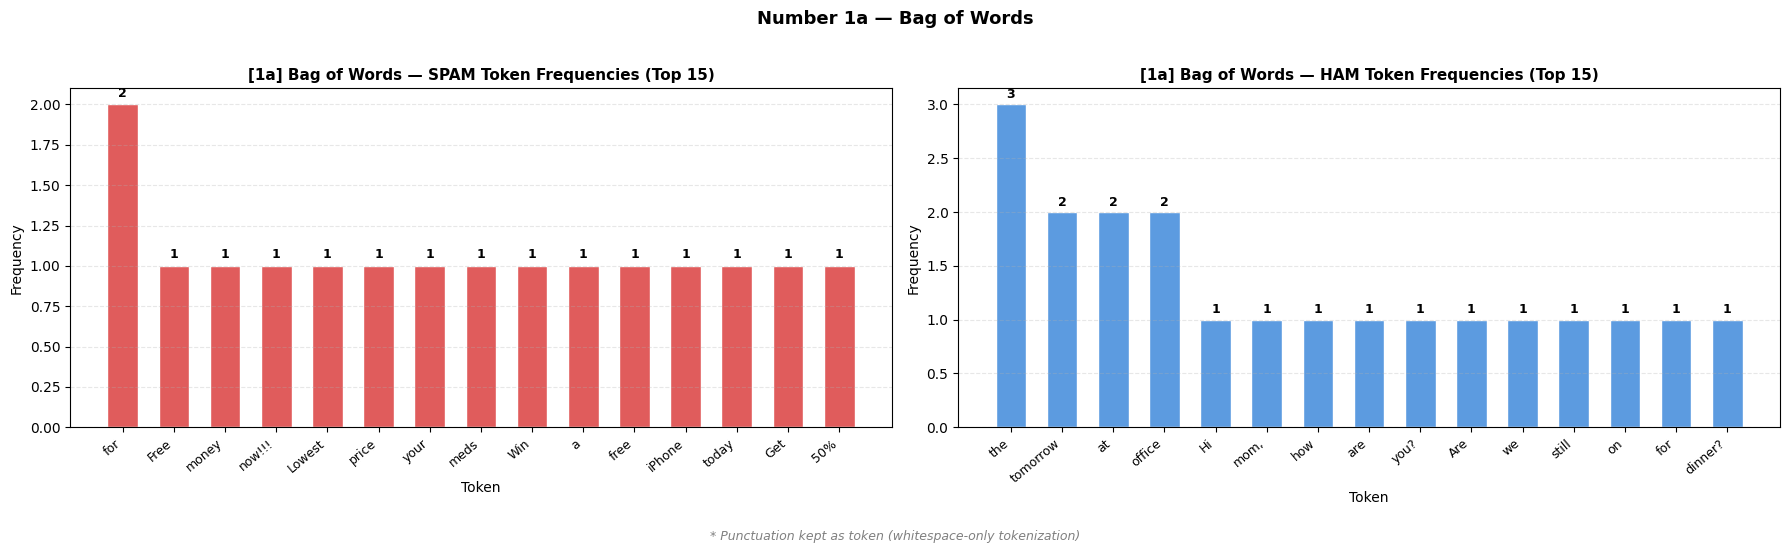

In [ ]:

# NUMBER 1 — Manual Naïve Bayes Implementation

#  1a. Generate Bag of Words 
def generate_bow(dataset):
    vocab = set()
    bow_per_class = {c: defaultdict(int) for c in CLASSES}
    for doc, label in dataset:
        for token in tokenize(doc):
            vocab.add(token)
            bow_per_class[label][token] += 1
    return sorted(vocab), bow_per_class

vocab, bow_per_class = generate_bow(dataset)

print(f"Vocabulary size : {len(vocab)}")
print(f"\nSPAM token counts: {dict(bow_per_class['SPAM'])}")
print(f"\nHAM  token counts: {dict(bow_per_class['HAM'])}")

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, cls in zip(axes, CLASSES):
    sorted_tokens = sorted(bow_per_class[cls].items(), key=lambda x: -x[1])[:15]
    labels = [w for w, _ in sorted_tokens]
    counts = [c for _, c in sorted_tokens]

    bars = ax.bar(labels, counts, color=COLORS[cls], edgecolor="white", width=0.6)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Token")
    ax.set_title(f"[1a] Bag of Words — {cls} Token Frequencies (Top 15)",
                fontweight="bold", fontsize=11)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

fig.text(0.5, -0.04,
        "* Punctuation kept as token (whitespace-only tokenization)",
        ha="center", fontsize=9, color="gray", style="italic")
fig.suptitle("Number 1a — Bag of Words", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("1a_bow.png", dpi=150, bbox_inches="tight")
plt.show()


  [1b] CLASS PRIORS
  P(SPAM) = 5/11 = 0.4545
  P(HAM) = 6/11 = 0.5455


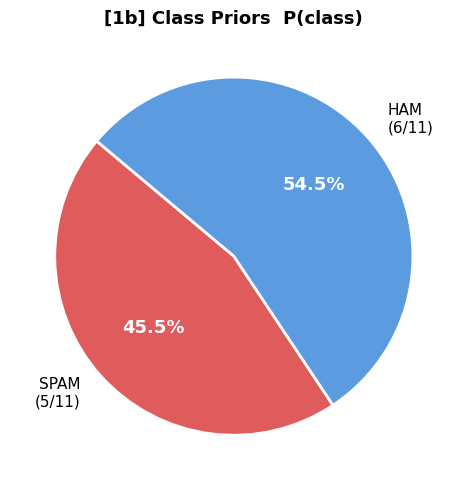

In [ ]:
#  1b. Calculate Class Priors 
total_docs   = len(dataset)
class_counts = {c: sum(1 for _, l in dataset if l == c) for c in CLASSES}
priors       = {c: class_counts[c] / total_docs for c in CLASSES}

print("=" * 45)
print("  [1b] CLASS PRIORS")
print("=" * 45)
for c in CLASSES:
    print(f"  P({c}) = {class_counts[c]}/{total_docs} = {priors[c]:.4f}")

#  Plot 
fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    [priors[c] for c in CLASSES],
    labels=[f"{c}\n({class_counts[c]}/{total_docs})" for c in CLASSES],
    autopct="%1.1f%%",
    colors=[COLORS[c] for c in CLASSES],
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    pctdistance=0.6,
    labeldistance=1.15,
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight("bold"); at.set_color("white")
for t in texts:
    t.set_fontsize(11)

ax.set_title("[1b] Class Priors  P(class)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("1b_priors.png", dpi=150, bbox_inches="tight")
plt.show()


[1c] Vocabulary size |V| = 48

Token                           P(w|SPAM)      P(w|HAM)
-------------------------------------------------------
3                                0.014286      0.024691
50%                              0.028571      0.012346
Are                              0.014286      0.024691
Can                              0.014286      0.024691
Click                            0.028571      0.012346
Free                             0.028571      0.012346
Get                              0.028571      0.012346
Hi                               0.014286      0.024691
Let's                            0.014286      0.024691
Lowest                           0.028571      0.012346
Meeting                          0.014286      0.024691
PM                               0.014286      0.024691
Team                             0.014286      0.024691
Win                              0.028571      0.012346
a                                0.028571      0.012346
are              

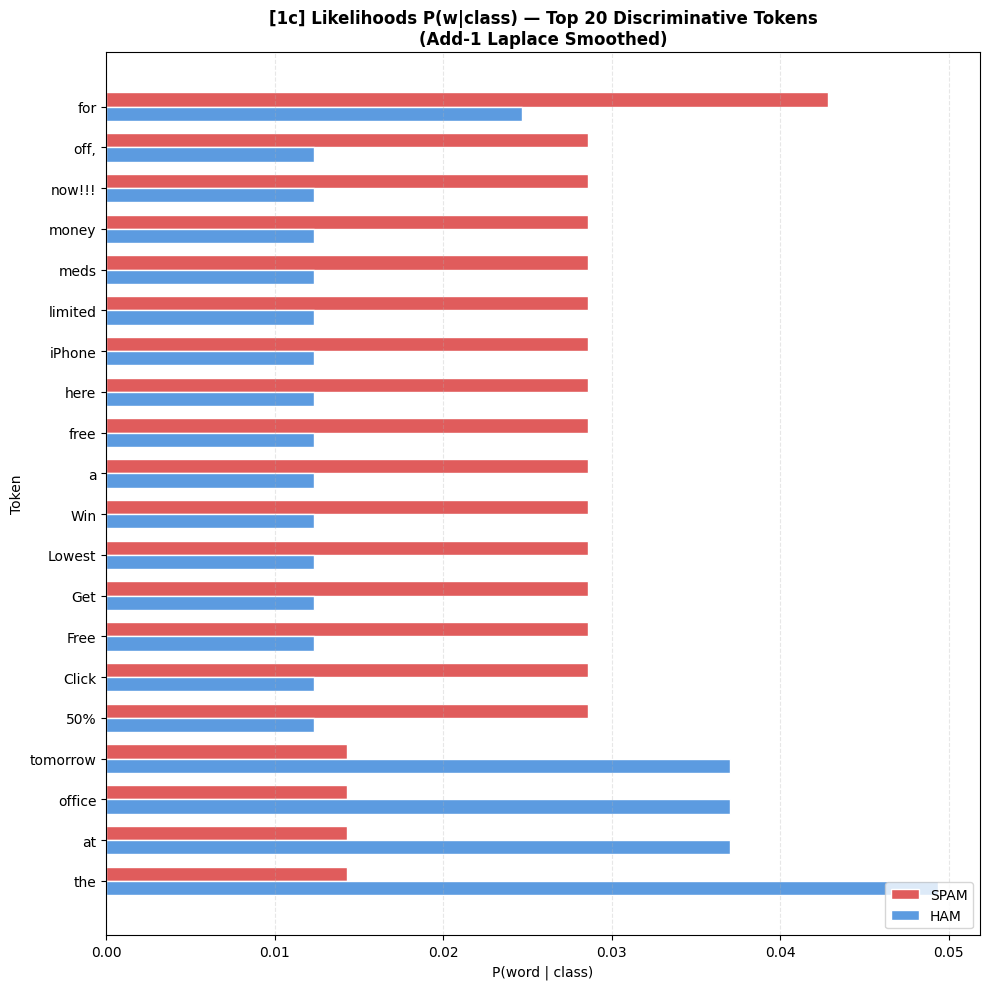

In [ ]:
#  1c. Calculate Likelihoods (Add-1 Laplace Smoothing) 
V = len(vocab)
raw_likelihoods = {}
log_likelihoods = {}

for c in CLASSES:
    total_words = sum(bow_per_class[c].values())
    raw_likelihoods[c] = {}
    log_likelihoods[c] = {}
    for word in vocab:
        count_wc = bow_per_class[c].get(word, 0)
        prob = (count_wc + 1) / (total_words + V)   # Add-1 Laplace smoothing
        raw_likelihoods[c][word] = prob
        log_likelihoods[c][word] = math.log(prob)   # log space avoids underflow

print(f"[1c] Vocabulary size |V| = {V}")
print(f"\n{'Token':<28} {'P(w|SPAM)':>12}  {'P(w|HAM)':>12}")
print("-" * 55)
for word in vocab:
    print(f"{word:<28} {raw_likelihoods['SPAM'][word]:>12.6f}  "
          f"{raw_likelihoods['HAM'][word]:>12.6f}")

#  Plot 
top_tokens = sorted(vocab,
    key=lambda w: abs(raw_likelihoods["SPAM"][w] - raw_likelihoods["HAM"][w]),
    reverse=True)[:20]
top_tokens = sorted(top_tokens, key=lambda w: raw_likelihoods["SPAM"][w])

y, height = np.arange(len(top_tokens)), 0.35

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y + height/2, [raw_likelihoods["SPAM"][t] for t in top_tokens],
        height, label="SPAM", color=COLORS["SPAM"], edgecolor="white")
ax.barh(y - height/2, [raw_likelihoods["HAM"][t]  for t in top_tokens],
        height, label="HAM",  color=COLORS["HAM"],  edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(top_tokens, fontsize=10)
ax.set_xlabel("P(word | class)")
ax.set_ylabel("Token")
ax.set_title("[1c] Likelihoods P(w|class) — Top 20 Discriminative Tokens\n"
             "(Add-1 Laplace Smoothed)", fontweight="bold", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("1c_likelihoods.png", dpi=150, bbox_inches="tight")
plt.show()


  [1d] CLASSIFICATION RESULTS — Manual Naïve Bayes

  i. "Limited offer, click here!"
     SPAM  : log score = -0.788457
     HAM   : log score = -0.606136  <-- PREDICTED
     => Predicted Class: HAM

  ii. "Meeting at 2 PM with the manager."
     SPAM  : log score = -17.782438
     HAM   : log score = -14.312731  <-- PREDICTED
     => Predicted Class: HAM


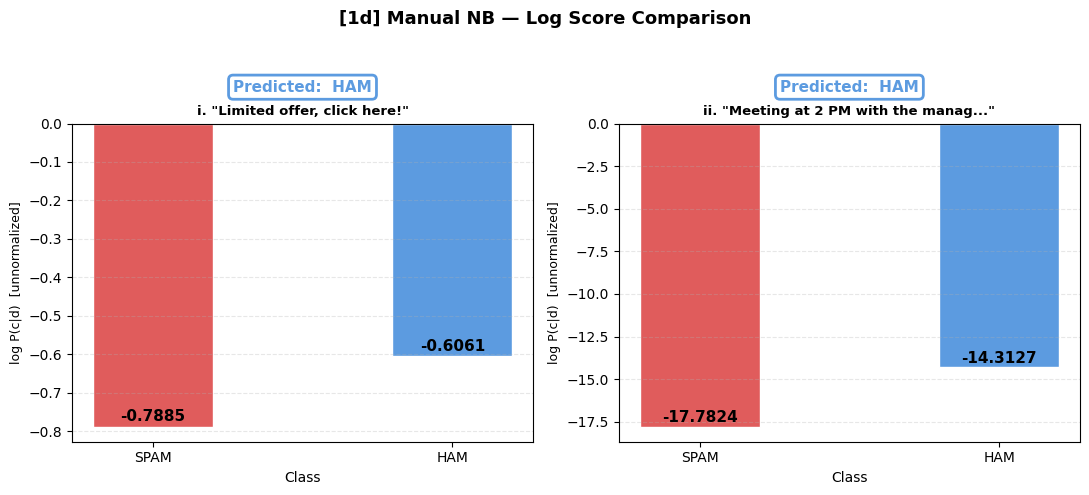

In [ ]:
#  1d. Classify Test Sentences 
def classify_manual(sentence):
    tokens    = tokenize(sentence)
    vocab_set = set(vocab)
    scores    = {}
    for c in CLASSES:
        score = math.log(priors[c])
        for token in tokens:
            if token in vocab_set:
                score += log_likelihoods[c][token]
            # Unknown tokens are ignored (standard NB practice)
        scores[c] = score
    predicted = max(scores, key=scores.get)
    return predicted, scores

manual_results = []
print("=" * 55)
print("  [1d] CLASSIFICATION RESULTS — Manual Naïve Bayes")
print("=" * 55)
for i, sent in enumerate(test_sentences):
    pred, scores = classify_manual(sent)
    manual_results.append((sent, pred, scores))
    label = ["i", "ii"][i]
    print(f"\n  {label}. \"{sent}\"")
    for c in CLASSES:
        marker = "  <-- PREDICTED" if c == pred else ""
        print(f"     {c:<6}: log score = {scores[c]:.6f}{marker}")
    print(f"     => Predicted Class: {pred}")

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("[1d] Manual NB — Log Score Comparison",
             fontweight="bold", fontsize=13)

for i, (ax, (sent, pred, scores)) in enumerate(zip(axes, manual_results)):
    vals       = [scores[c] for c in CLASSES]
    bar_colors = [COLORS[c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=bar_colors, edgecolor="white", width=0.4)

    y_pad = (max(vals) - min(vals)) * 0.03
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + y_pad,
                f"{v:.4f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

    label = ["i", "ii"][i]
    ax.set_title(f'{label}. "{sent[:30]}{"..." if len(sent)>30 else ""}"',
                 fontsize=9.5, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("log P(c|d)  [unnormalized]", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.text(0.5, 1.10, f"Predicted:  {pred}",
            transform=ax.transAxes, ha="center", fontsize=11, fontweight="bold",
            color=COLORS[pred],
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS[pred], lw=2))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("1d_classification.png", dpi=150, bbox_inches="tight")
plt.show()


[2] Vocabulary size : 48
    Classes          : ['HAM' 'SPAM']
    Class log priors : [-0.6061358  -0.78845736]


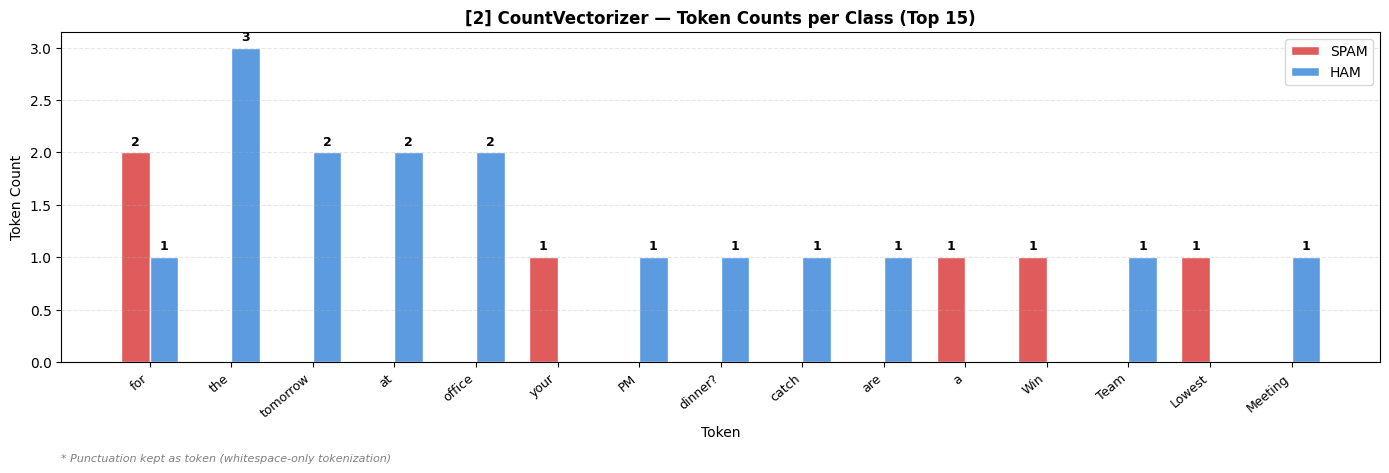

In [ ]:
# NUMBER 2 — Scikit-Learn Multinomial Naïve Bayes

#  Train Pipeline 
# CountVectorizer: whitespace tokenizer, case preserved
# MultinomialNB:   alpha=1.0 = Add-1 Laplace smoothing (same as Number 1)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="word",
        tokenizer=lambda x: x.split(),  # whitespace-only; punctuation kept as token
        lowercase=False,                 # preserve case
        token_pattern=None,
    )),
    ("classifier", MultinomialNB(alpha=1.0)),
])

pipeline.fit(X_train, y_train)
vectorizer = pipeline.named_steps["vectorizer"]
clf        = pipeline.named_steps["classifier"]
feat_names = vectorizer.get_feature_names_out()
sk_classes = list(clf.classes_)

print(f"[2] Vocabulary size : {len(feat_names)}")
print(f"    Classes          : {clf.classes_}")
print(f"    Class log priors : {clf.class_log_prior_}")

#  Plot: Token Counts per Class 
ham_counts_raw  = clf.feature_count_[sk_classes.index("HAM")]
spam_counts_raw = clf.feature_count_[sk_classes.index("SPAM")]
total_counts    = ham_counts_raw + spam_counts_raw
top15_idx       = np.argsort(total_counts)[-15:][::-1]
top15_tokens    = feat_names[top15_idx]
top15_ham       = ham_counts_raw[top15_idx]
top15_spam      = spam_counts_raw[top15_idx]

x, width = np.arange(len(top15_tokens)), 0.35
fig, ax  = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width/2, top15_spam, width, label="SPAM", color=COLORS["SPAM"], edgecolor="white")
b2 = ax.bar(x + width/2, top15_ham,  width, label="HAM",  color=COLORS["HAM"],  edgecolor="white")

for bar, v in list(zip(b1, top15_spam)) + list(zip(b2, top15_ham)):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                str(int(v)), ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(top15_tokens, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Token Count")
ax.set_xlabel("Token")
ax.set_title("[2] CountVectorizer — Token Counts per Class (Top 15)",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.annotate("* Punctuation kept as token (whitespace-only tokenization)",
            xy=(0, -0.30), xycoords="axes fraction", fontsize=8,
            color="gray", style="italic")
plt.tight_layout()
plt.savefig("2_bow.png", dpi=150, bbox_inches="tight")
plt.show()


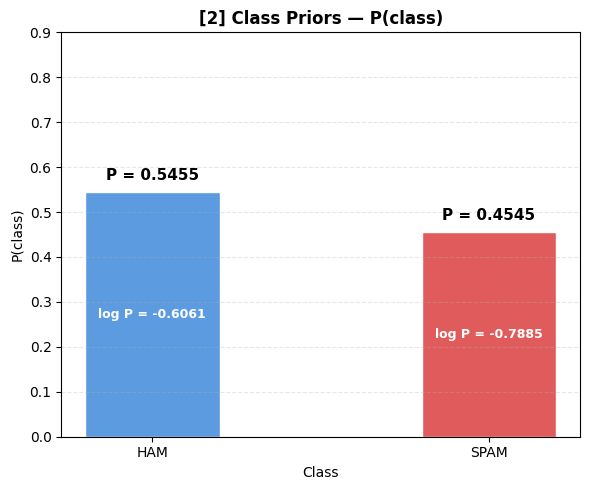

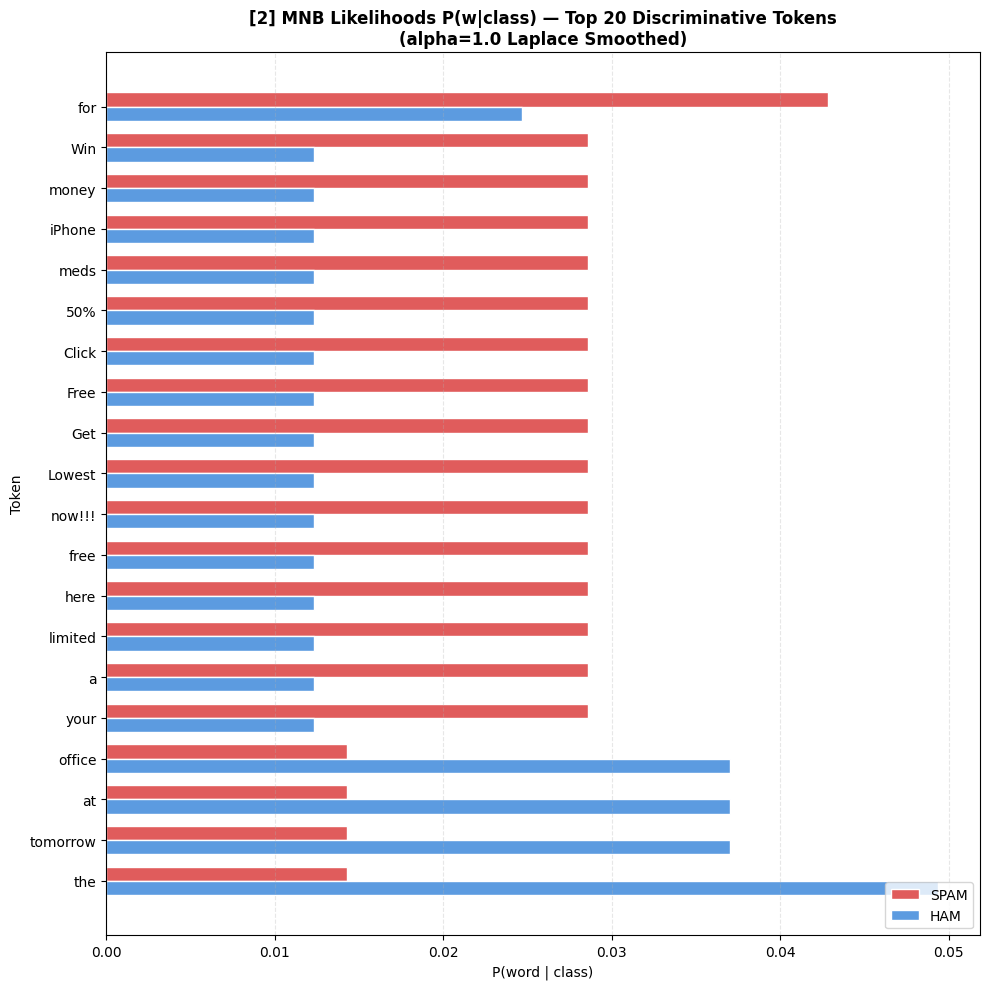

In [7]:
#  Plot: Priors 
raw_p  = np.exp(clf.class_log_prior_)
log_p  = clf.class_log_prior_
colors = [COLORS[c] for c in sk_classes]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(sk_classes, raw_p, color=colors, edgecolor="white", width=0.4)
for bar, rp, lp in zip(bars, raw_p, log_p):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.02,
            f"P = {rp:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()/2,
            f"log P = {lp:.4f}", ha="center", va="center",
            fontsize=9, color="white", fontweight="bold")

ax.set_ylim(0, 0.9)
ax.set_ylabel("P(class)")
ax.set_xlabel("Class")
ax.set_title("[2] Class Priors — P(class)", fontweight="bold", fontsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("2_priors.png", dpi=150, bbox_inches="tight")
plt.show()

#  Plot: Likelihoods 
lk_ham  = np.exp(clf.feature_log_prob_[sk_classes.index("HAM")])
lk_spam = np.exp(clf.feature_log_prob_[sk_classes.index("SPAM")])

top20_idx  = np.argsort(np.abs(lk_spam - lk_ham))[-20:]
top20_tok  = feat_names[top20_idx]
top20_ham  = lk_ham[top20_idx]
top20_spam = lk_spam[top20_idx]

so = np.argsort(top20_spam)
top20_tok, top20_ham, top20_spam = top20_tok[so], top20_ham[so], top20_spam[so]

y, h = np.arange(len(top20_tok)), 0.35
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y + h/2, top20_spam, h, label="SPAM", color=COLORS["SPAM"], edgecolor="white")
ax.barh(y - h/2, top20_ham,  h, label="HAM",  color=COLORS["HAM"],  edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(top20_tok, fontsize=10)
ax.set_xlabel("P(word | class)")
ax.set_ylabel("Token")
ax.set_title("[2] MNB Likelihoods P(w|class) — Top 20 Discriminative Tokens\n"
             "(alpha=1.0 Laplace Smoothed)", fontweight="bold", fontsize=12)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("2_likelihoods.png", dpi=150, bbox_inches="tight")
plt.show()


  [2a] CLASSIFICATION RESULTS — Scikit-Learn MNB

  i. "Limited offer, click here!"
     HAM   : P = 0.545455  <-- PREDICTED
     SPAM  : P = 0.454545
     => Predicted Class: HAM

  ii. "Meeting at 2 PM with the manager."
     HAM   : P = 0.969813  <-- PREDICTED
     SPAM  : P = 0.030187
     => Predicted Class: HAM


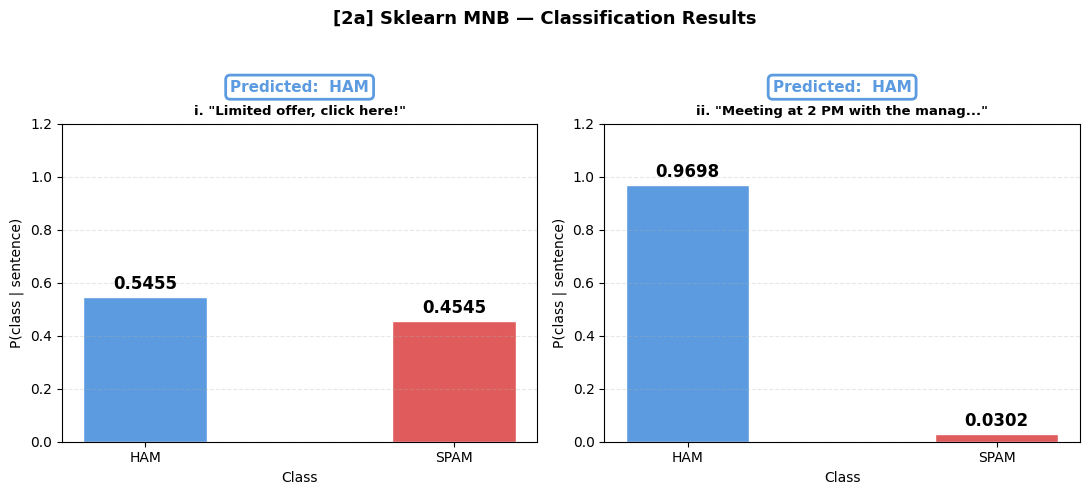

In [8]:
#  2a. Classify Test Sentences 
predictions = pipeline.predict(test_sentences)
proba       = pipeline.predict_proba(test_sentences)

print("=" * 55)
print("  [2a] CLASSIFICATION RESULTS — Scikit-Learn MNB")
print("=" * 55)
for i, (sent, pred, prob) in enumerate(zip(test_sentences, predictions, proba)):
    label = ["i", "ii"][i]
    print(f"\n  {label}. \"{sent}\"")
    for cls, p in zip(sk_classes, prob):
        marker = "  <-- PREDICTED" if cls == pred else ""
        print(f"     {cls:<6}: P = {p:.6f}{marker}")
    print(f"     => Predicted Class: {pred}")

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("[2a] Sklearn MNB — Classification Results",
             fontweight="bold", fontsize=13)

for i, (ax, sent, pred, prob) in enumerate(zip(axes, test_sentences, predictions, proba)):
    bars = ax.bar(sk_classes, prob,
                  color=[COLORS[c] for c in sk_classes],
                  edgecolor="white", width=0.4)
    for bar, p in zip(bars, prob):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.015,
                f"{p:.4f}", ha="center", va="bottom",
                fontsize=12, fontweight="bold")

    label = ["i", "ii"][i]
    ax.set_title(f'{label}. "{sent[:30]}{"..." if len(sent)>30 else ""}"',
                 fontsize=9.5, fontweight="bold")
    ax.set_ylim(0, 1.2)
    ax.set_xlabel("Class")
    ax.set_ylabel("P(class | sentence)")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.text(0.5, 1.10, f"Predicted:  {pred}",
            transform=ax.transAxes, ha="center", fontsize=11, fontweight="bold",
            color=COLORS[pred],
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS[pred], lw=2))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("2a_classification.png", dpi=150, bbox_inches="tight")
plt.show()
